# Mouse embryogenesis atlas

This tutorial jointly models eight MOSTA Stereo-seq stages from E9.5 to E16.5.
Download the stage H5AD files from the
[MOSTA data portal](https://db.cngb.org/stomics/mosta/) and assemble them with
`tutorials/prepare/prepare_embryogenesis.py`. We summarize temporal deployment
across all GEPs and then visualize five programs highlighted in the manuscript.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import scanpy as sc
from scipy import sparse

import sort


stages = ["E9.5", "E10.5", "E11.5", "E12.5", "E13.5", "E14.5", "E15.5", "E16.5"]

Load the outer-joined count atlas. Each location retains its developmental
stage, anatomical annotation and original spatial coordinates.

In [2]:
adata = sc.read_h5ad(Path("../data/embryogenesis/embryogenesis_counts.h5ad"))
adata

AnnData object with n_obs × n_vars = 520815 × 29678
    obs: 'annotation', 'slice_id'
    uns: 'tutorial_provenance'
    obsm: 'spatial'

Reproduce the manuscript preprocessing: retain locations with at least 50
detected genes, keep genes detected in at least 0.1% of retained locations,
normalize and log-transform, and select 8,000 stage-aware highly variable
genes.

In [3]:
sc.pp.calculate_qc_metrics(adata, inplace=True, percent_top=None)
adata = adata[adata.obs["n_genes_by_counts"] >= 50].copy()

min_cells = max(1, int(np.ceil(adata.n_obs * 0.001)))
detected_per_gene = np.asarray((adata.X > 0).sum(axis=0)).ravel()
adata = adata[:, detected_per_gene >= min_cells].copy()

sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(
    adata,
    n_top_genes=8_000,
    batch_key="slice_id",
    flavor="seurat_v3",
)
adata = adata[:, adata.var["highly_variable"]].copy()
adata.X = sparse.csr_matrix(adata.X, dtype=np.float32)
adata

AnnData object with n_obs × n_vars = 520389 × 8000
    obs: 'annotation', 'slice_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'tutorial_provenance', 'log1p', 'hvg'
    obsm: 'spatial'

Construct an eight-neighbour graph independently within each developmental
stage, then combine the graphs using the atlas row indices.

In [4]:
sort.build_per_sample_graph(
    adata, n_neighbors=8, sample_key="slice_id"
)

Building spatial graphs for 8 samples (k=8)...
  [8/8] Processed
Combined Laplacian: (520389, 520389), 4,683,501 non-zeros


AnnData object with n_obs × n_vars = 520389 × 8000
    obs: 'annotation', 'slice_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'tutorial_provenance', 'log1p', 'hvg', 'spatial_laplacian'
    obsm: 'spatial'

The embryogenesis fit uses stronger profile sparsity and a different balance
between spatial and orthogonality penalties than the common biological-data
settings. Initialization uses the package defaults and the fixed random seed.

In [5]:
result = sort.fit(
    adata,
    n_components=60,
    use_highly_variable=False,
    alpha=0.4,
    beta=0.2,
    lambda_l1_W=0.4,
    lambda_l1_Q=800,
)
result

SORT: 520,389 locations x 8,000 genes; 60 components
Finished in 1800.1 s
Stored .obsm['X_sort'] (520389, 60) and .varm['sort_signatures'] (8000, 60)


SORTResult(W=(520389, 60) spots_x_components, Q=(8000, 60) genes_x_components, background_component=0, fit_time=1800.1s)

Mean activity within each stage reveals early, intermediate and progressively
increasing temporal programs. Rows are ordered by peak stage and temporal
center of mass for display only.

In [6]:
stage_labels = adata.obs["slice_id"].astype(str).to_numpy()
stage_means = np.vstack([
    result.W[stage_labels == stage, 1:].mean(axis=0) for stage in stages
])
stage_means /= np.maximum(stage_means.max(axis=0, keepdims=True), 1e-12)
peak = stage_means.argmax(axis=0)
center = (stage_means * np.arange(len(stages))[:, None]).sum(axis=0) / np.maximum(
    stage_means.sum(axis=0), 1e-12
)
order = np.lexsort((center, peak))

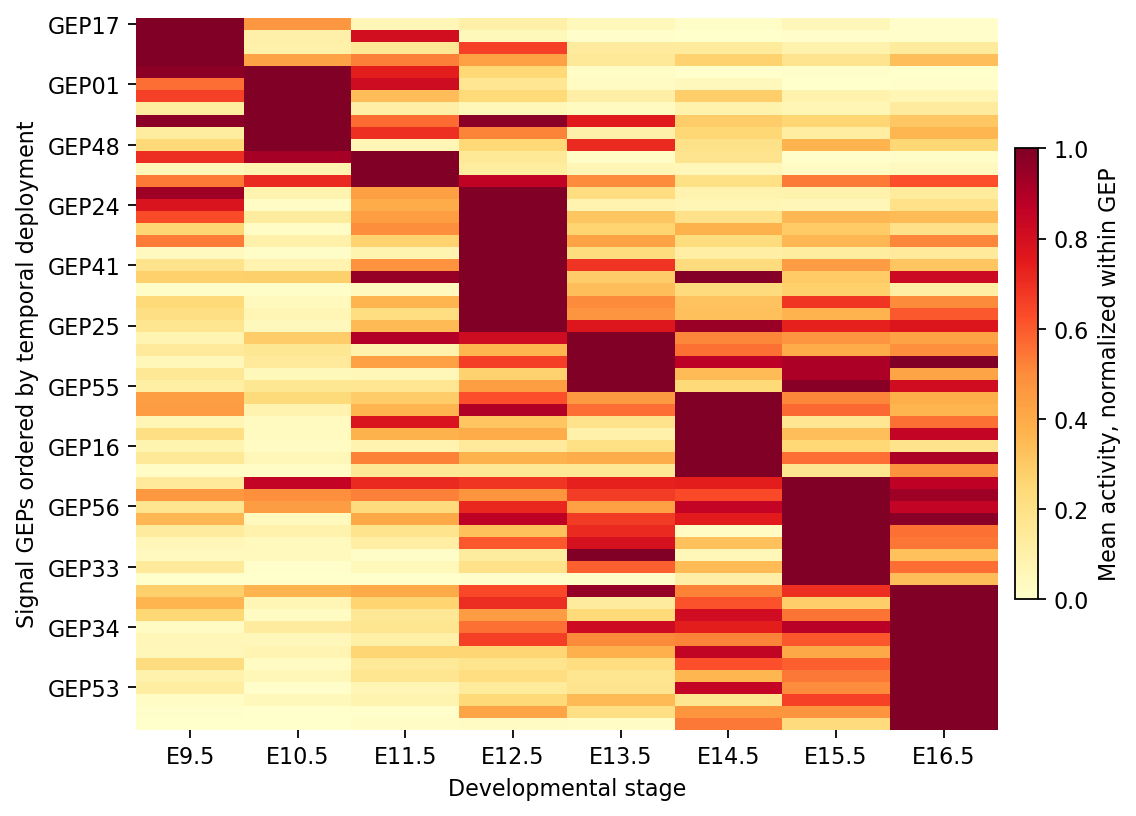

In [7]:
fig, ax = plt.subplots(figsize=(7.2, 5.2))
image = ax.imshow(stage_means[:, order].T, cmap="YlOrRd", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(np.arange(len(stages)), stages)
ax.set_yticks(np.arange(0, 59, 5), [f"GEP{i + 1:02d}" for i in order[::5]])
ax.set_xlabel("Developmental stage")
ax.set_ylabel("Signal GEPs ordered by temporal deployment")
for spine in ax.spines.values():
    spine.set_visible(False)
fig.colorbar(image, ax=ax, fraction=0.025, pad=0.02,
             label="Mean activity, normalized within GEP")
fig.tight_layout()
plt.show()

Five representative GEPs illustrate chondrogenic, epithelial, neural and two
distinct contractile programs. Each figure follows one program across all
eight stages. The top row shows SORT activity and the lower row highlights
the corresponding atlas annotation.

In [8]:
examples = [
    (25, "Chondrogenic", "Cartilage"),
    (31, "Epithelial", "Epidermis"),
    (2, "Neural", "Brain"),
    (6, "Sarcomeric", "Muscle"),
    (43, "Smooth-contractile", "Smooth muscle"),
]
coordinates = np.asarray(adata.obsm["spatial"], dtype=float)
annotations = adata.obs["annotation"].astype(str).to_numpy(dtype=str)

# Recenter each stage while retaining one common x/y scale. Smaller embryos
# therefore remain smaller instead of being stretched to fill each subplot.
stage_maps = {}
widths, heights = [], []
for stage in stages:
    mask = stage_labels == stage
    xy = coordinates[mask].copy()
    xy -= (xy.min(axis=0) + xy.max(axis=0)) / 2
    stage_maps[stage] = (mask, xy)
    widths.append(np.ptp(xy[:, 0]))
    heights.append(np.ptp(xy[:, 1]))
half_width = max(widths) * 0.53
half_height = max(heights) * 0.53


def plot_program(gep, label, annotation):
    positive = result.W[:, gep][result.W[:, gep] > 0]
    upper = np.quantile(positive, 0.995) if len(positive) else 1.0
    fig, axes = plt.subplots(2, len(stages), figsize=(14.0, 4.2))

    for column, stage in enumerate(stages):
        mask, xy = stage_maps[stage]
        activity = result.W[mask, gep]
        order = np.argsort(activity)
        axes[0, column].scatter(
            xy[order, 0], xy[order, 1], c=activity[order], s=0.08,
            cmap="Reds", vmin=0, vmax=upper, linewidths=0, rasterized=True,
        )

        selected = np.char.find(annotations[mask], annotation) >= 0
        axes[1, column].scatter(
            xy[:, 0], xy[:, 1], c="#E5E5E5", s=0.08,
            linewidths=0, rasterized=True,
        )
        axes[1, column].scatter(
            xy[selected, 0], xy[selected, 1], c="#4C78A8", s=0.10,
            linewidths=0, rasterized=True,
        )
        axes[0, column].set_title(stage, fontsize=8)

        for row in range(2):
            axes[row, column].set_xlim(-half_width, half_width)
            axes[row, column].set_ylim(half_height, -half_height)
            axes[row, column].set_aspect("equal", adjustable="box")
            axes[row, column].axis("off")

    fig.text(0.012, 0.64, "SORT activity", ha="left", va="center", fontsize=8)
    fig.text(0.012, 0.25, annotation, ha="left", va="center", fontsize=8)
    colorbar = fig.colorbar(
        axes[0, 0].collections[0], ax=axes[0], orientation="horizontal",
        fraction=0.035, pad=0.02, aspect=35,
    )
    colorbar.set_label("GEP activity", fontsize=8)
    colorbar.ax.tick_params(labelsize=7, length=2)
    fig.suptitle(f"GEP{gep:02d} — {label}", fontsize=10, y=0.99)
    fig.subplots_adjust(
        left=0.10, right=0.995, bottom=0.10, top=0.89,
        wspace=0.01, hspace=0.02,
    )
    plt.show()

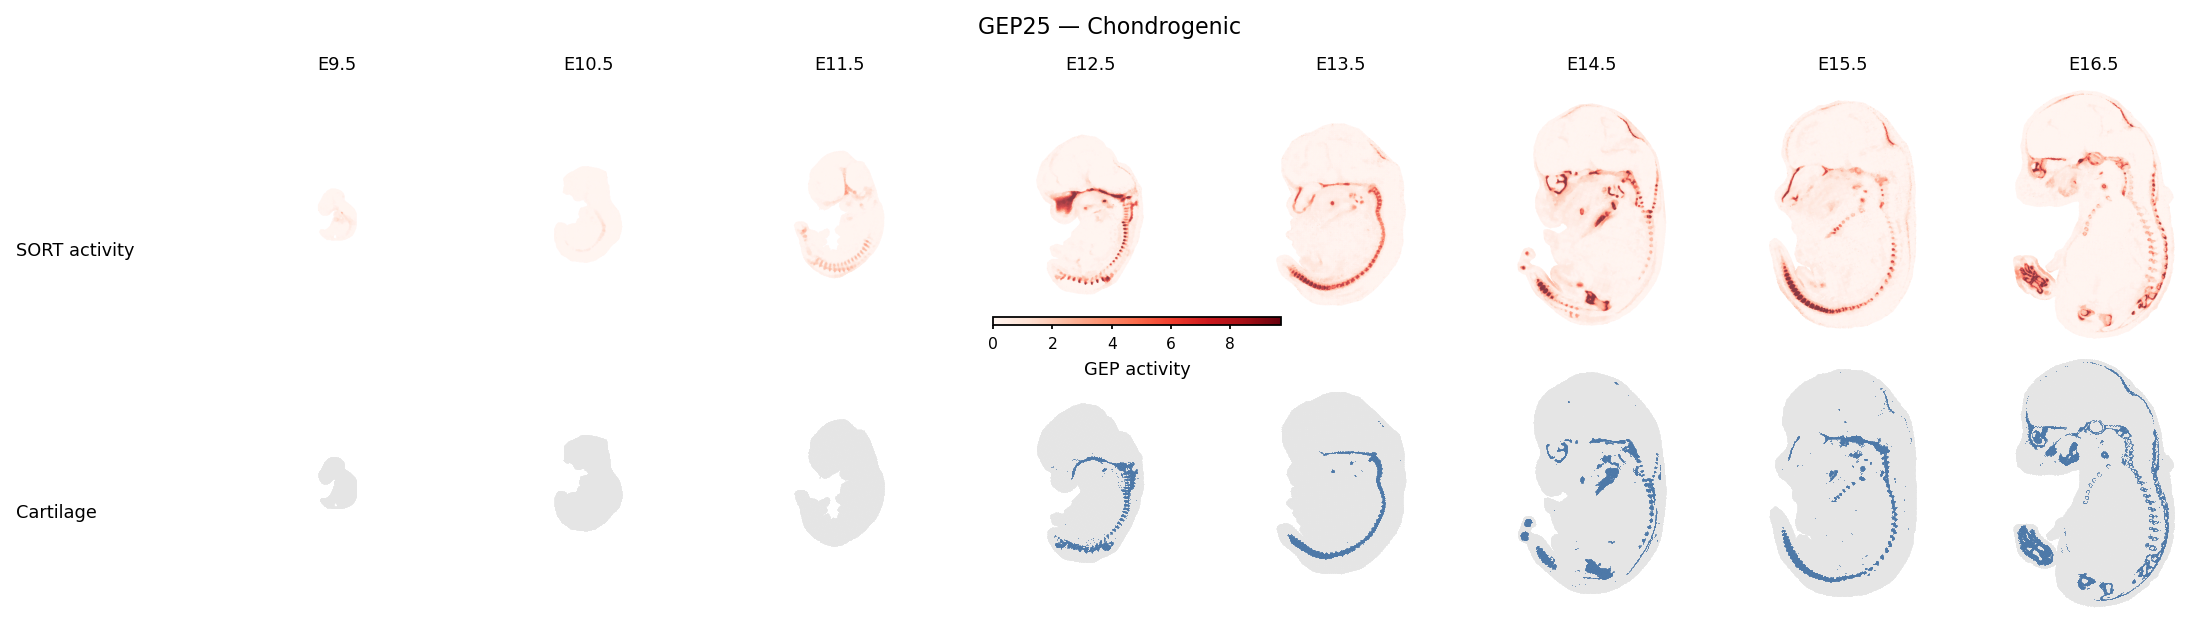

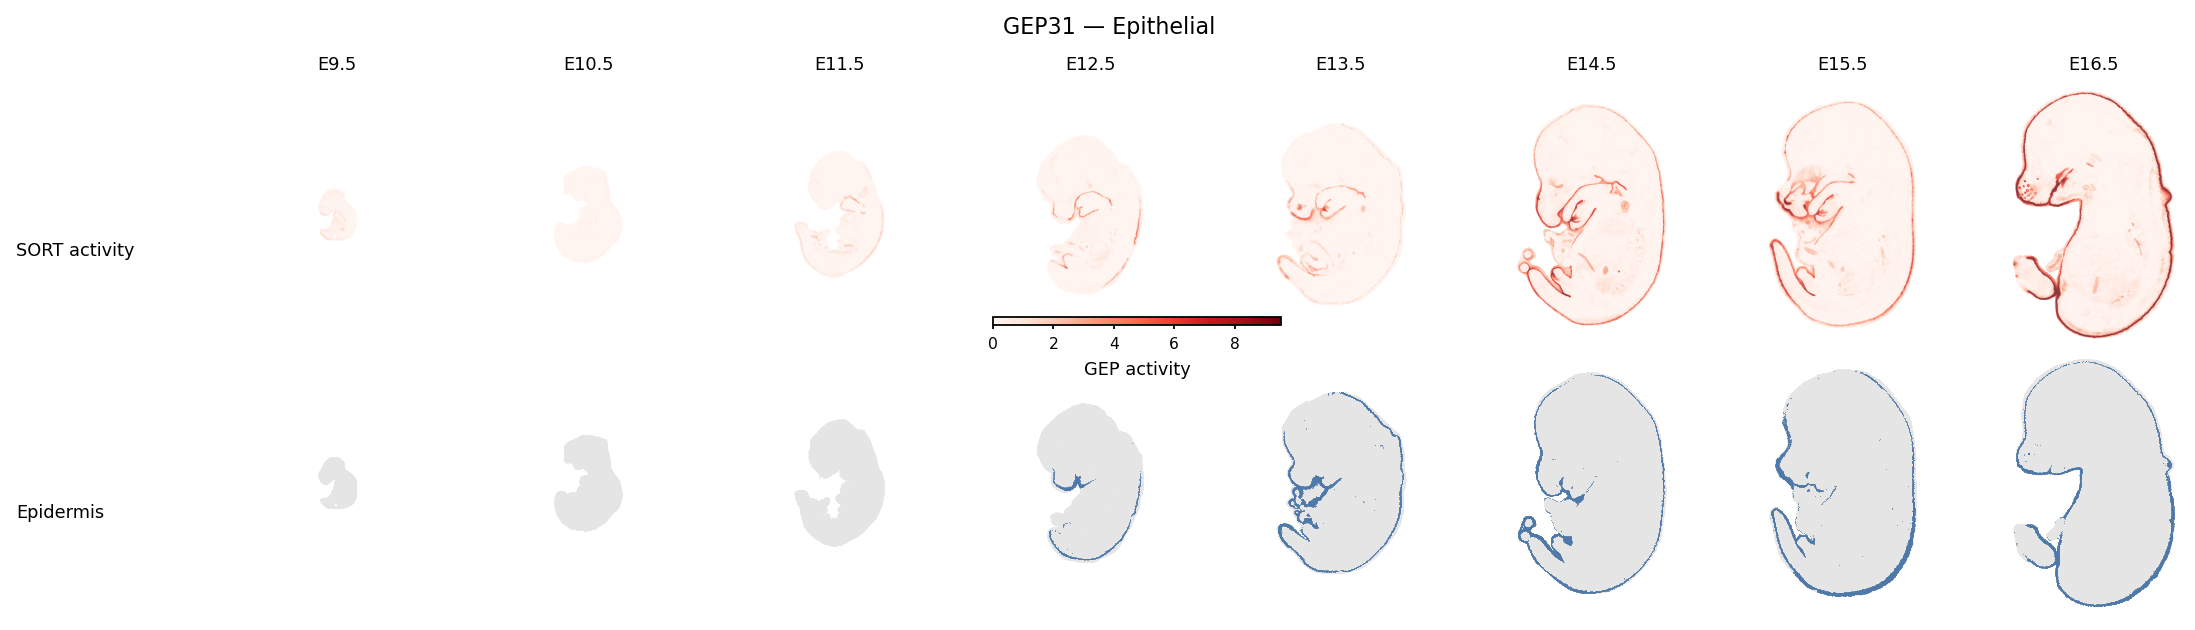

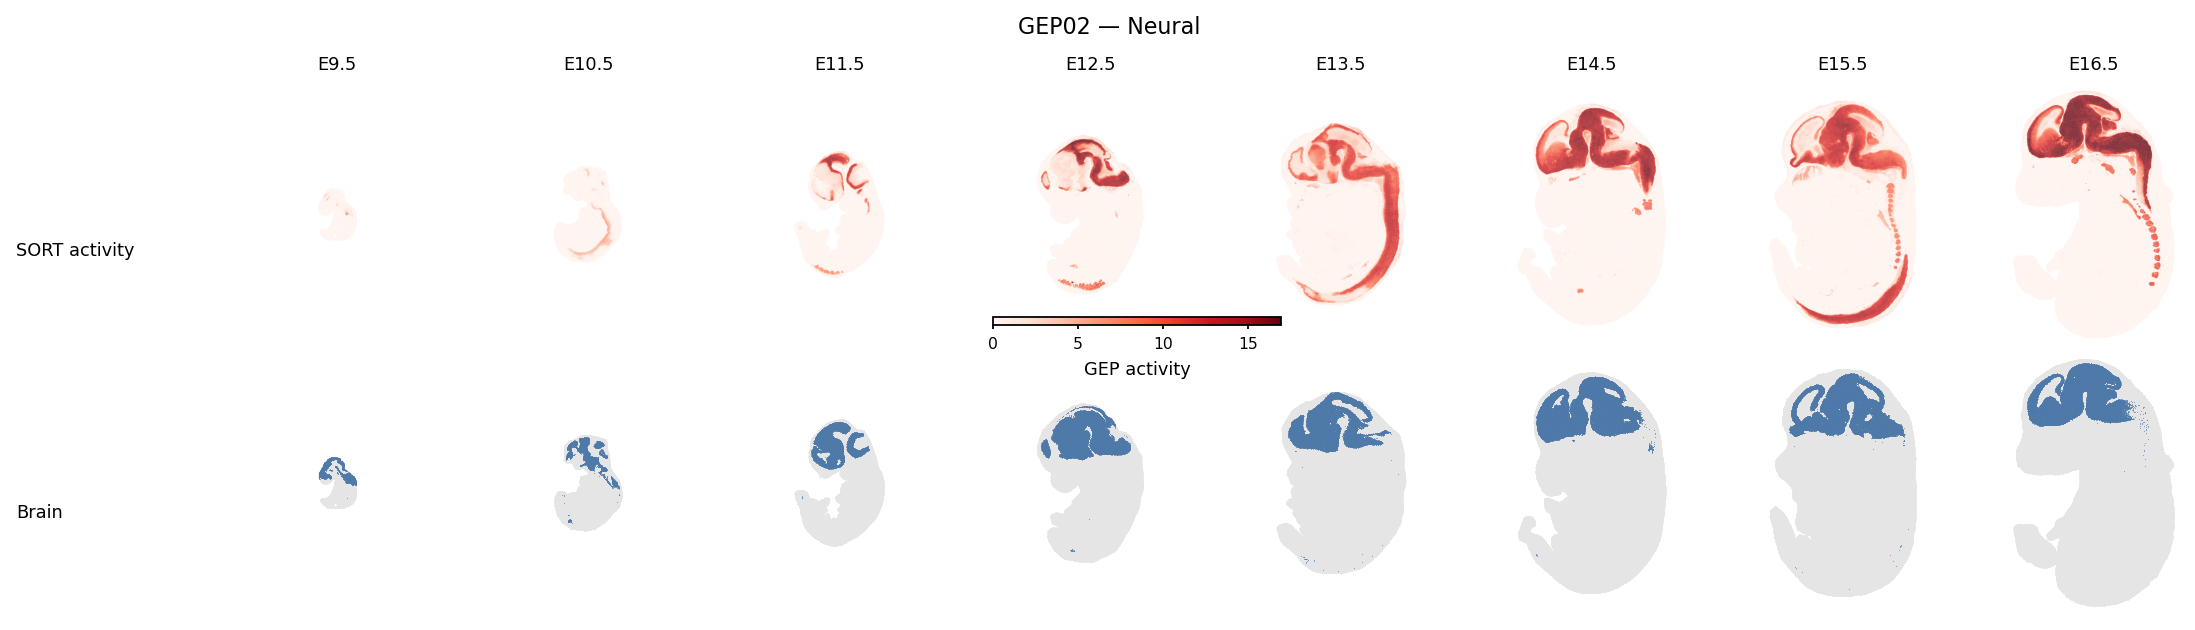

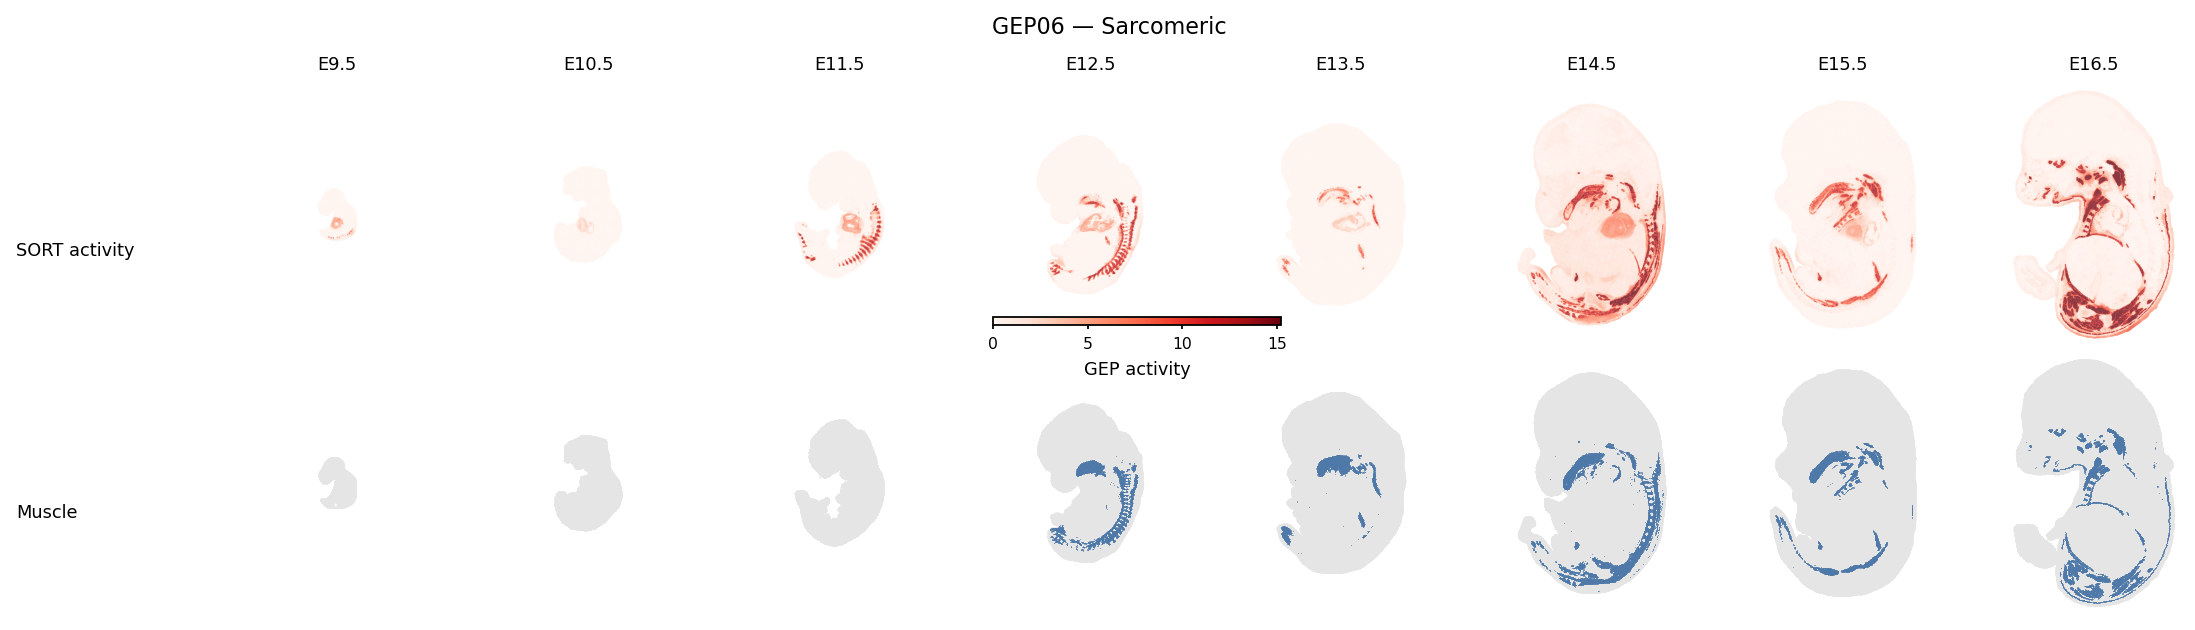

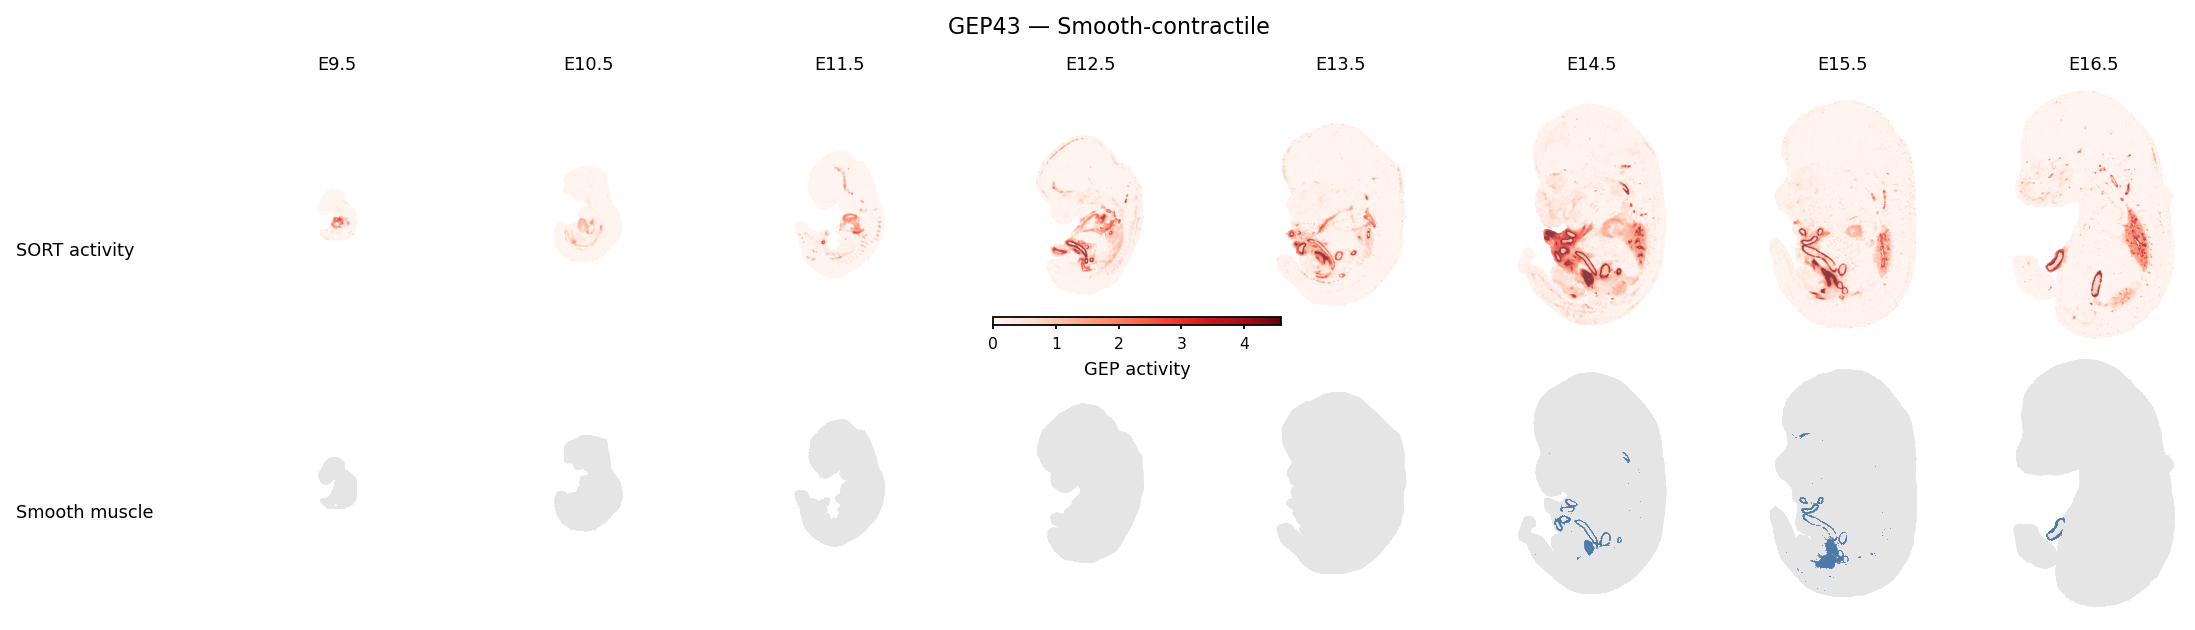

In [9]:
for example in examples:
    plot_program(*example)